In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

In [2]:
from scripts.data_loading import load_data

In [3]:
def gen_overview(df, name):
    print(f"\n{name}: Data Overview:")
    print(f"Shape: {df.shape}")
    print(f"Data Type: \n{df.dtypes}")
    print(f"Missing Values: \n{df.isnull().sum()}")
    print(f"First 20 rows: \n{df.head(20)}")

In [4]:
def check_missing_values(df, name):
    print(f"\n{name}: Missing Values:")
    missing = df.isnull().sum()
    print(missing[missing>0])
    print(f"Percentage of missing values: \n{missing/len(df) *100}")

In [5]:
def review_text_analysis(df, name):
    print("\n{name}: Review Comment Missing:")

    missing_title = df["review_comment_title"].isnull().sum()
    missing_msg = df["review_comment_message"].isnull().sum()

    print(f"Missing review titles: {missing_title}")
    print(f"Missing review messages: {missing_msg}")

In [6]:
def check_duplicate_rows(df, name):
    print(f"\n{name}: Duplicate Rows:")
    duplicates = df.duplicated().sum()
    print(f"Duplicate rows: {duplicates}")
    if duplicates > 0:
        print(df[df.duplicated()])

In [7]:
def descriptive_statistics(df, name):
    print(f"\n{name}: Descriptive Statistics:")
    print(df.describe())

In [8]:
def plot_histogram(df, name):
    print(f"\n{name}: Histogram: Numerical Features")
    # Explicitly check for numeric types
    numeric_df = df.select_dtypes(include=["float64", "int64"])

    # If no numeric columns, print a warning
    if numeric_df.empty:
        print(f"No numerical columns available for plotting in {name}.")
        return

    # Plot histogram for numeric columns
    numeric_df.hist(bins=30, figsize=(10, 8))
    plt.tight_layout()
    plt.show()

In [9]:
def plot_boxplot(df, name):
    print(f"\n{name}: Boxplot: Numerical Features")
    for col in df.select_dtypes(include=["float64", "int64"]).columns:
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot of {col}")
        plt.show()

In [10]:
def detect_outliers(df, name):
    print(f"\n{name} - Outlier Detection")
    for column in df.select_dtypes(include=["float64", "int64"]).columns:
        z_scores = stats.zscore(df[column].dropna())
        abs_z_scores = np.abs(z_scores)
        outliers = (abs_z_scores > 3)
        print(f"Outliers for {column}: {df[column][outliers]}")

In [11]:
def correlation_matrix(df, name):
    print(f"\n{name} - Correlation Matrix")
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=["float64", "int64"])

    # Check if there are numeric columns before computing correlation
    if numeric_df.empty:
        print(f"No numerical columns available for correlation in {name}.")
        return

    # Compute the correlation matrix
    corr_matrix = numeric_df.corr()
    print(corr_matrix)

    # Plot the correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.tight_layout()
    plt.show()

In [12]:
# Linear Regression Function
def linear_regression(df, x_column, y_column):
    # Check if the columns exist in the DataFrame
    if x_column not in df.columns or y_column not in df.columns:
        print(f"Error: Columns {x_column} and/or {y_column} not found in the DataFrame.")
        return

    print(f"\nLinear Regression: {x_column} vs {y_column}")

    # Independent variable (X) - reshape for sklearn
    X = df[[x_column]].values.reshape(-1, 1)

    # Dependent variable (Y)
    y = df[y_column].values

    # Create and fit the model
    model = LinearRegression()
    model.fit(X, y)

    # Predictions
    y_pred = model.predict(X)

    # Plot the data and the regression line
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='blue', label='Actual data')
    plt.plot(X, y_pred, color='red', label='Regression line')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f'Linear Regression: {x_column} vs {y_column}')
    plt.legend()
    plt.show()

    print(f"Model coefficients: {model.coef_}")
    print(f"Model intercept: {model.intercept_}")

In [13]:
def review_score_dist(df, name):
    print(f"\n{name}: Review score distribution:")

    print(order_reviews["review_score"].value_counts().sort_index())

    sns.countplot(x="review_score", data=df)
    plt.title("Distribution of Review Scores")
    plt.xlabel("Review score")
    plt.ylabel("Count")
    plt.show()

In [14]:
def explore_data(orders_df, order_items_df, products_df, customers_df, order_payments_df, order_reviews_df, sellers_df, geo_location_df):
    gen_overview(orders_df, "Orders")
    gen_overview(order_items_df, "Order Items")
    gen_overview(order_payments_df, "Order Payments")
    gen_overview(products_df, "Products")
    gen_overview(customers_df, "Customers")
    gen_overview(order_reviews_df, "Order Reviews")
    gen_overview(sellers_df, "Sellers")
    gen_overview(geo_location_df, "Geo Location")

    check_missing_values(orders_df, "Orders")
    check_missing_values(order_items_df, "Order Items")
    check_missing_values(order_payments_df, "Order Payments")
    check_missing_values(products_df, "Products")
    check_missing_values(customers_df, "Customers")
    check_missing_values(order_reviews_df, "Order Reviews")
    check_missing_values(sellers_df, "Sellers")
    check_missing_values(geo_location_df, "Geo Location")

    check_duplicate_rows(orders_df, "Orders")
    check_duplicate_rows(order_items_df, "Order Items")
    check_duplicate_rows(order_payments_df, "Order Payments")
    check_duplicate_rows(products_df, "Products")
    check_duplicate_rows(customers_df, "Customers")
    check_duplicate_rows(order_reviews_df, "Order Reviews")
    check_duplicate_rows(sellers_df, "Sellers")
    check_duplicate_rows(geo_location_df, "Geo Location")

    descriptive_statistics(orders_df, "Orders")
    descriptive_statistics(order_items_df, "Order Items")
    descriptive_statistics(order_payments_df, "Order Payments")
    descriptive_statistics(products_df, "Products")
    descriptive_statistics(customers_df, "Customers")
    descriptive_statistics(order_reviews_df, "Order Reviews")
    descriptive_statistics(sellers_df, "Sellers")
    descriptive_statistics(geo_location_df, "Geo Location")

    review_score_dist(order_reviews_df, "Order Reviews")
    review_text_analysis(order_reviews_df, "Order Reviews")

    plot_histogram(orders_df, "Orders")
    plot_boxplot(orders_df, "Orders")

    detect_outliers(orders_df, "Orders")
    correlation_matrix(orders_df, "Orders")

    plot_histogram(products_df, "Products")
    plot_boxplot(products_df, "Products")

    linear_regression(order_items_df, 'price', 'freight_value')


Orders: Data Overview:
Shape: (99441, 8)
Data Type: 
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
Missing Values: 
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
First 20 rows: 
                            order_id                       customer_id  \
0   e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1   53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2   47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a

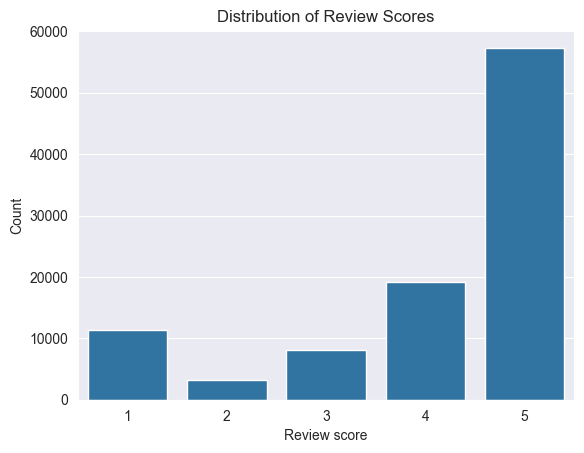


{name}: Review Comment Missing:
Missing review titles: 87656
Missing review messages: 58247

Orders: Histogram: Numerical Features
No numerical columns available for plotting in Orders.

Orders: Boxplot: Numerical Features

Orders - Outlier Detection

Orders - Correlation Matrix
No numerical columns available for correlation in Orders.

Products: Histogram: Numerical Features


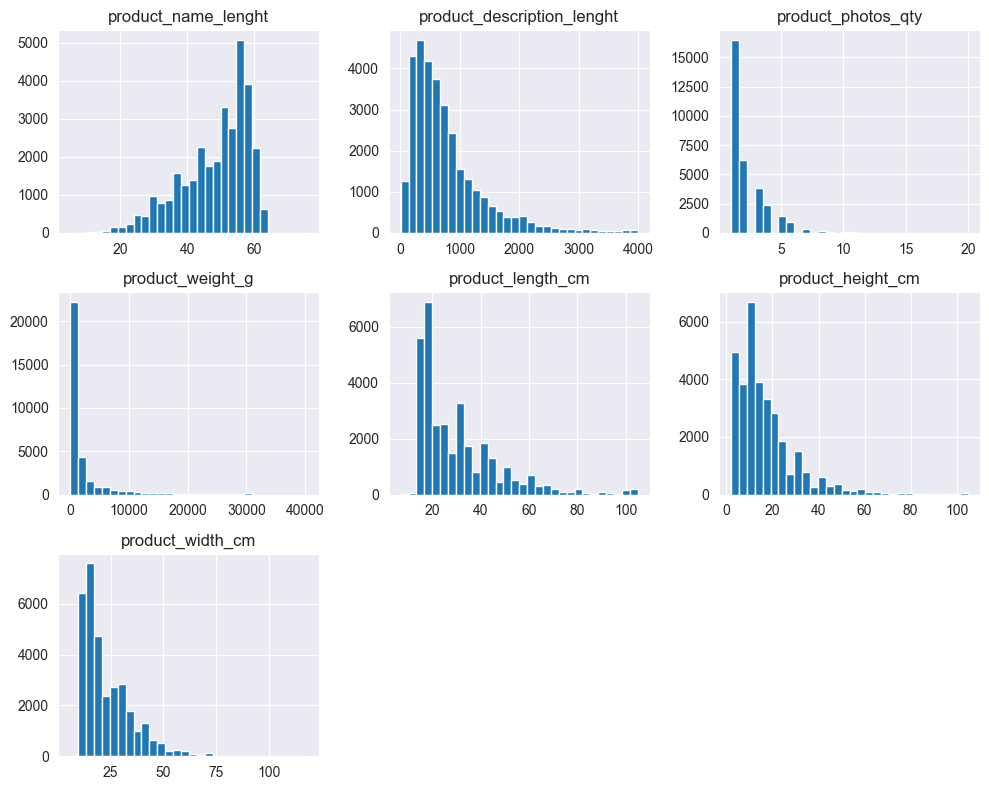


Products: Boxplot: Numerical Features


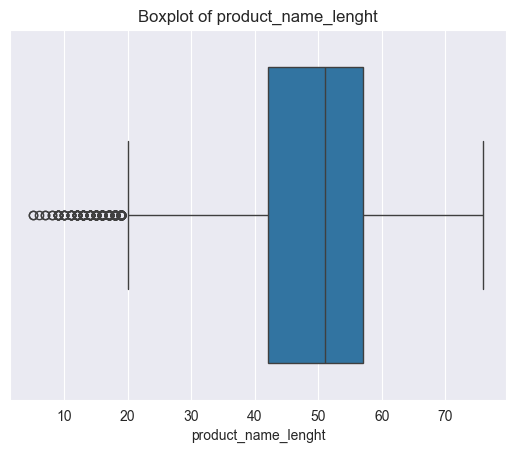

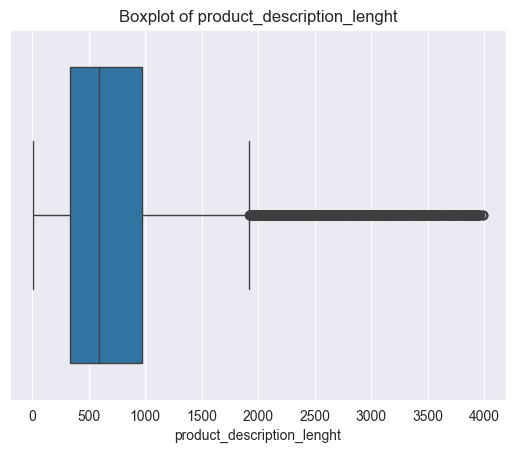

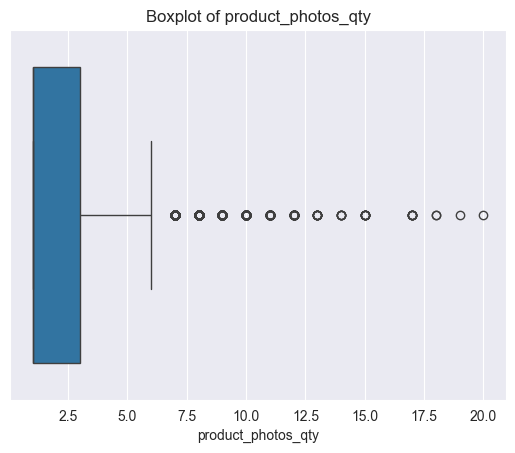

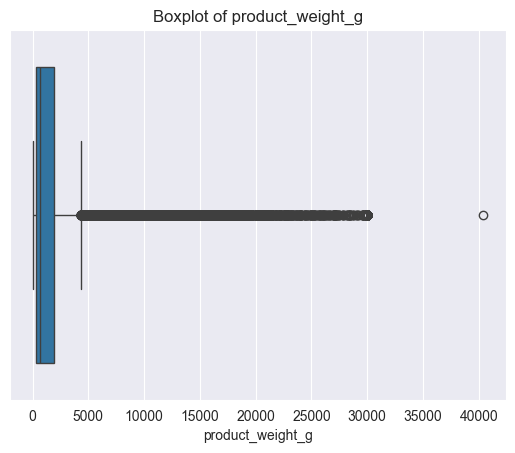

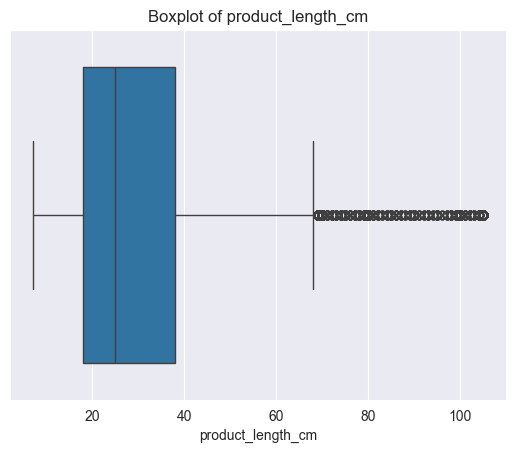

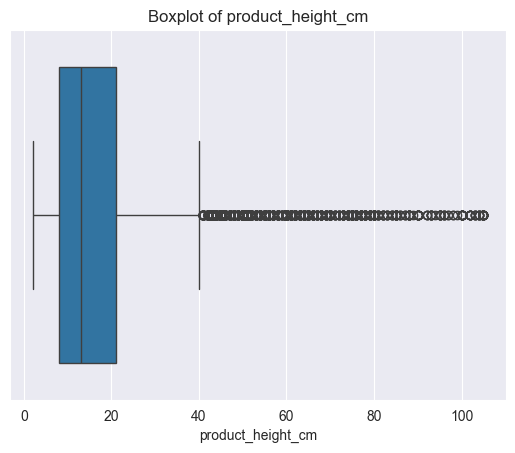

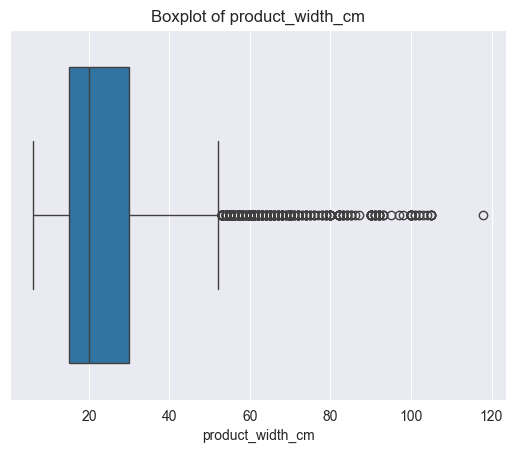


Linear Regression: price vs freight_value


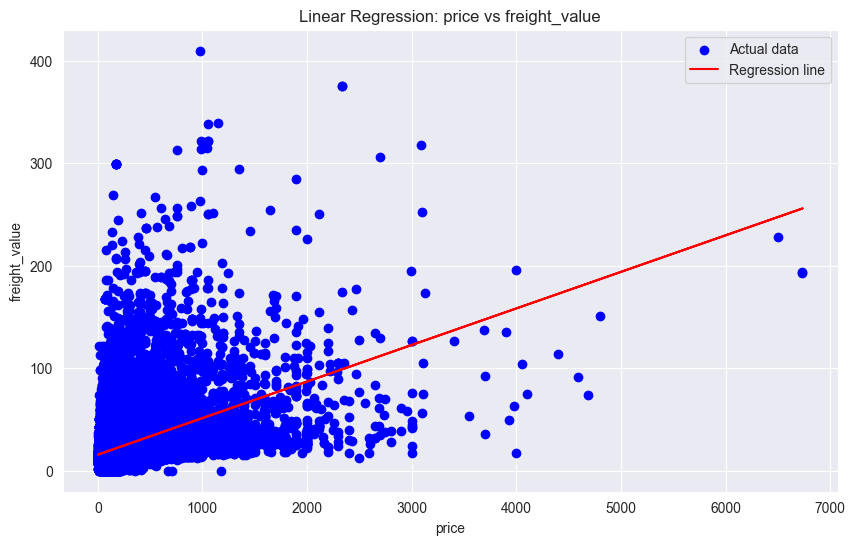

Model coefficients: [0.0356529]
Model intercept: 15.688664776209627


In [15]:
if __name__ == "__main__":
    # Load the data
    (
        orders,
        order_items,
        order_payments,
        order_reviews,
        products,
        customers,
        sellers,
        geo_location
    ) = load_data()

    # Explore the data
    explore_data(
        orders,
        order_items,
        products,
        customers,
        order_payments,
        order_reviews,
        sellers,
        geo_location
    )